
          DINOv3 Simple Head (Full Fine-Tuning) Classification Pipeline

[INFO] PyTorch Version: 2.7.1+cu128
[INFO] Data Loading Mode: In-Memory (Preloading to RAM)
[INFO] Using Device: cuda
[INFO] Early Stopping Patience: 20 epochs
[INFO] Training for up to 2 epochs.

                            Phase 1: Data Preparation
[INFO] Discovered 5 classes: Herpes, Melanoma, Monkeypox, Sarampion, Varicela
[INFO] Pre-loading all images into RAM. This may take a moment...


--> Loading test data: 100%|█████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 87.06it/s]


[SUCCESS] All image data has been pre-loaded into memory.
 - Dataset sizes: Train=2000, Val=250, Test=500

                             Phase 2: Model Training
[INFO] Starting training for up to 2 epochs...
[INFO] Early stopping is active with patience=20.


Epoch [001/002] | LRs (Head/Backbone): 1.00e-04/1.00e-05 | Train Loss: 1.2890 | Train Acc: 0.6215 | Val Loss: 1.0036 | Val Acc: 0.8000
    > Validation loss improved to 1.0036. Saving best model.


Epoch [002/002] | LRs (Head/Backbone): 0.00e+00/0.00e+00 | Train Loss: 0.8047 | Train Acc: 0.8565 | Val Loss: 0.7376 | Val Acc: 0.8680
    > Validation loss improved to 0.7376. Saving best model.

[SUCCESS] Model training completed.


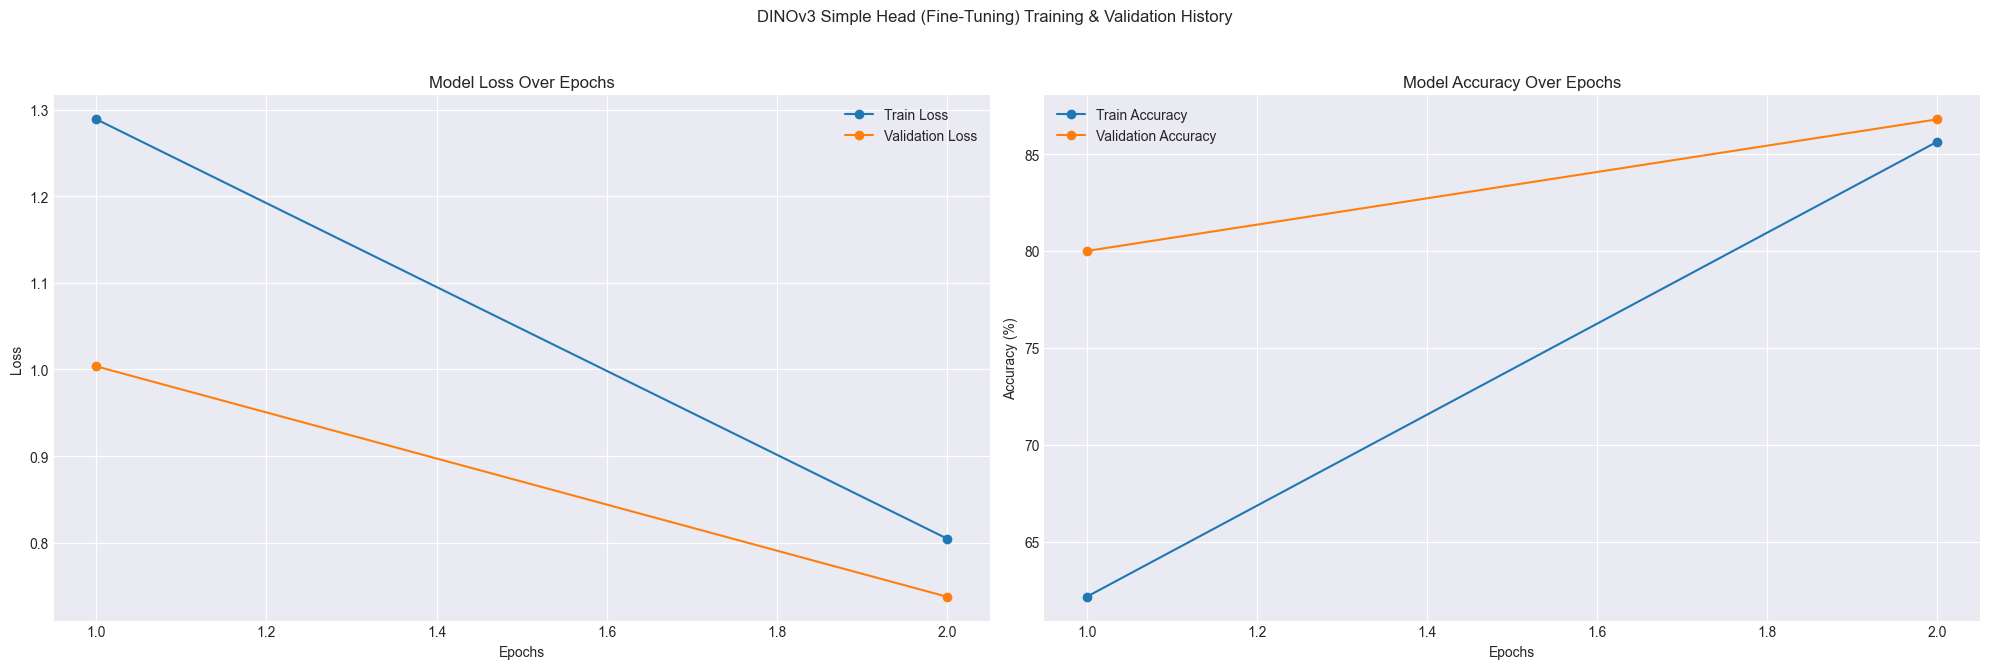


Saved training history plot to: full_results_DINOv3_SimpleHead_unfreeze\training_history.png

OVERALL TEST PERFORMANCE


--> Evaluating on Test Set: 100%|████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.29s/it]


              precision    recall  f1-score   support

      Herpes     0.8455    0.9300    0.8857       100
    Melanoma     0.9804    1.0000    0.9901       100
   Monkeypox     0.8202    0.7300    0.7725       100
   Sarampion     0.8365    0.8700    0.8529       100
    Varicela     0.7368    0.7000    0.7179       100

    accuracy                         0.8460       500
   macro avg     0.8439    0.8460    0.8438       500
weighted avg     0.8439    0.8460    0.8438       500


--- Overall Scalar Metrics ---
Accuracy: 0.8460
Macro ROC AUC: 0.9700
Cohen's Kappa: 0.8075
Matthews CorrCoef: 0.8080


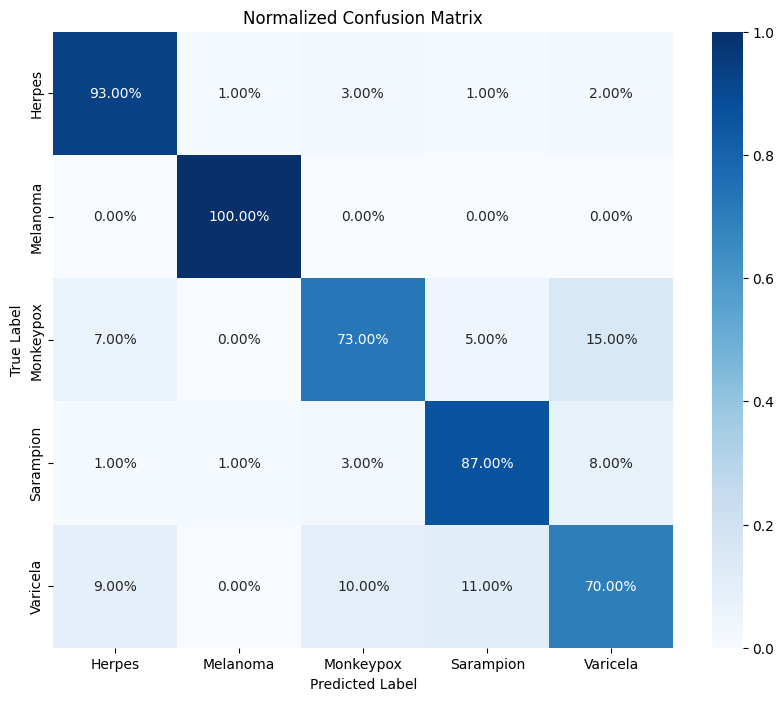


Saved normalized confusion matrix to: full_results_DINOv3_SimpleHead_unfreeze\confusion_matrix.png


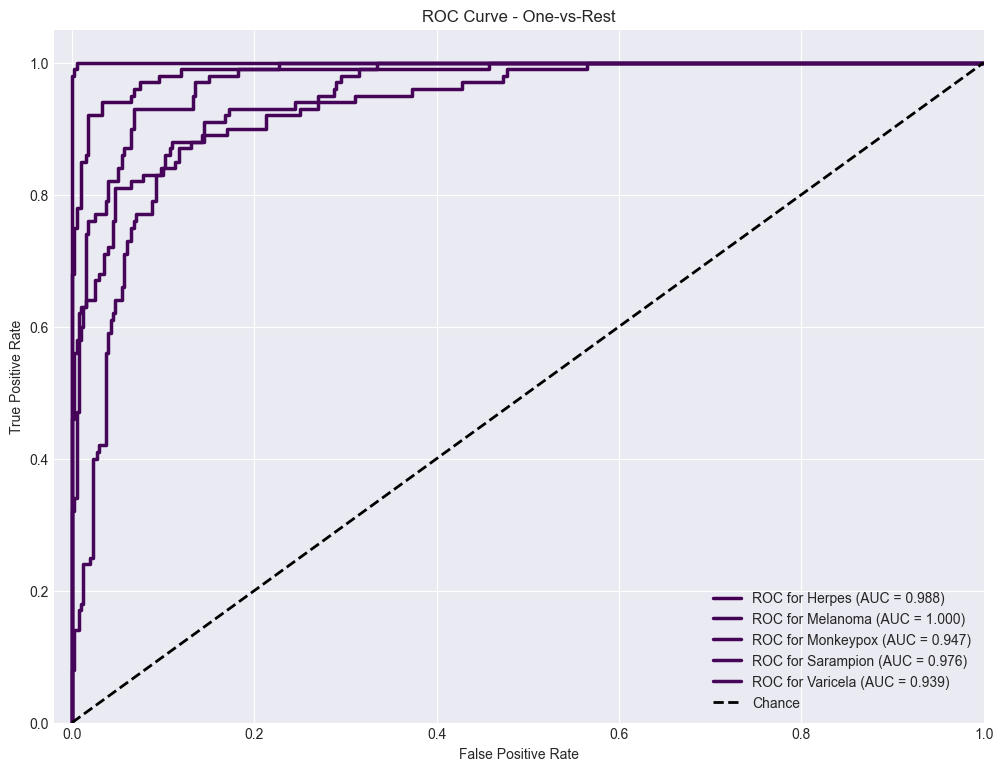


Saved ROC curves plot to: full_results_DINOv3_SimpleHead_unfreeze\roc_curves.png


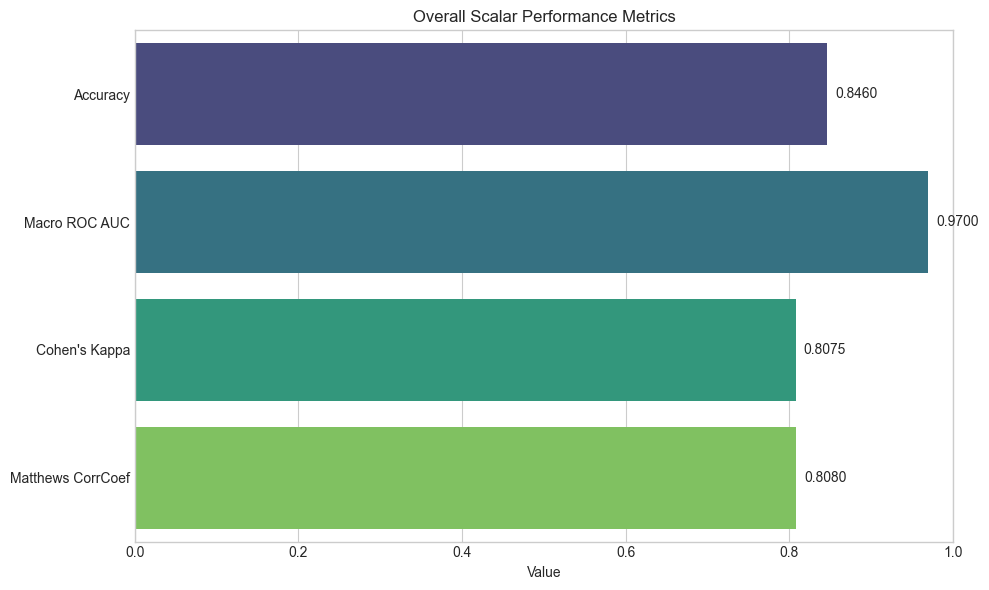


Saved scalar metrics plot to: full_results_DINOv3_SimpleHead_unfreeze\scalar_metrics.png

Done.


In [1]:
# ==============================================================================
# Project:
# DINOv3 with a Simple Linear Head for Skin Disease Classification (Full Fine-Tuning)
#
# Description:
# This script fine-tunes the entire DINOv3 Vision Transformer using discriminative
# learning rates. A smaller learning rate is applied to the pretrained backbone
# to gently adapt its weights, while a larger learning rate is used for the
# randomly initialized Simple Linear Head.
#
# Author:
# Gemini (Adapted from DINOv3 DSAF script)
#
# Date:
# September 24, 2025
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import math
import warnings
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Core ML/DL Libraries
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from torch.amp import GradScaler, autocast

# Evaluation & Utilities
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize

# Suppress non-critical warnings
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ==============================================================================================
# I. SETUP AND CONFIGURATION
# ==============================================================================================
config = {
    # --- Hardware & Performance Tuning ---
    "DEVICE": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "AMP_ENABLED": True,
    "NUM_WORKERS": 0,

    # --- File Paths ---
    "DATA_DIR": r"D:\AIUB\Neural\Synthetic_Skin_Disease_Dataset",
    "RESULTS_DIR": "_full_Dataset_DINOv3_Simple_(unfreeze)", # <-- MODIFIED

    # --- Model & Training Hyperparameters ---
    "MODEL_NAME": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "IMAGE_SIZE": 224,
    "BATCH_SIZE": 128,
    "NUM_EPOCHS": 2,
    "LEARNING_RATE": 1e-4, # For the classification head
    "BACKBONE_LEARNING_RATE": 1e-5, # <-- ADDED: Smaller LR for the backbone
    "WEIGHT_DECAY": 1e-4,
    "WARMUP_EPOCHS": 1,
    "EARLY_STOPPING_PATIENCE": 20,
    "LABEL_SMOOTHING": 0.1,

    # --- Reproducibility ---
    "RANDOM_SEED": 42
}

# --- Create results directory ---
os.makedirs(config["RESULTS_DIR"], exist_ok=True)
config["MODEL_SAVE_PATH_BEST"] = os.path.join(config["RESULTS_DIR"], "DINOv3_SimpleHead_FineTuned_best_model.pth") # <-- MODIFIED


# --- Set Seed for Reproducible Experiments ---
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

set_seed(config["RANDOM_SEED"])


# --- Initial Setup Verification ---
print("\n" + "="*80)
print(" " * 10 + "DINOv3 Simple Head (Full Fine-Tuning) Classification Pipeline") # <-- MODIFIED
print("="*80)
print(f"\n[INFO] PyTorch Version: {torch.__version__}")
print(f"[INFO] Data Loading Mode: In-Memory (Preloading to RAM)")
print(f"[INFO] Using Device: {config['DEVICE']}")
print(f"[INFO] Early Stopping Patience: {config['EARLY_STOPPING_PATIENCE']} epochs")
print(f"[INFO] Training for up to {config['NUM_EPOCHS']} epochs.")
print("="*80)


# ==============================================================================================
# II. DATA PREPARATION & HANDLING
# ==============================================================================================
class InMemoryDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        image, label = self.data_list[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

cpu_transforms = transforms.Compose([
    transforms.Resize((config["IMAGE_SIZE"], config["IMAGE_SIZE"])),
    transforms.ToTensor()
])

class GPUAugmentation(nn.Module):
    def __init__(self):
        super().__init__()
        self.transforms = nn.Sequential(
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        )
    @torch.no_grad()
    def forward(self, x):
        return self.transforms(x)

print("\n" + "="*80)
print(" " * 28 + "Phase 1: Data Preparation")
print("="*80)

try:
    temp_datasets = {
        x: datasets.ImageFolder(os.path.join(config["DATA_DIR"], x))
        for x in ['train', 'val', 'test']
    }
    class_names = temp_datasets['train'].classes
    num_classes = len(class_names)
    config["NUM_CLASSES"] = num_classes

    print(f"[INFO] Discovered {num_classes} classes: {', '.join(class_names)}")
    print("[INFO] Pre-loading all images into RAM. This may take a moment...")

    preloaded_data = {'train': [], 'val': [], 'test': []}
    for split in ['train', 'val', 'test']:
        for path, label in tqdm(temp_datasets[split].samples, desc=f"--> Loading {split} data"):
            with Image.open(path).convert("RGB") as img:
                image_tensor = cpu_transforms(img)
                preloaded_data[split].append((image_tensor, label))

    image_datasets = {
        'train': InMemoryDataset(preloaded_data['train']),
        'val': InMemoryDataset(preloaded_data['val']),
        'test': InMemoryDataset(preloaded_data['test'])
    }
    
    dataloaders = {
        x: DataLoader(
            image_datasets[x],
            batch_size=config["BATCH_SIZE"],
            shuffle=(x == 'train'),
            num_workers=config["NUM_WORKERS"],
            pin_memory=True
        )
        for x in ['train', 'val', 'test']
    }
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
    
    print(f"[SUCCESS] All image data has been pre-loaded into memory.")
    print(f" - Dataset sizes: Train={dataset_sizes['train']}, Val={dataset_sizes['val']}, Test={dataset_sizes['test']}")

except FileNotFoundError as e:
    print(f"\n[ERROR] Dataset not found. Please check the path in config['DATA_DIR'].")
    print(f"Details: {e}")
    exit()

# ==============================================================================================
# III. MODEL, OPTIMIZER, AND SCHEDULER INITIALIZATION
# ==============================================================================================

# <-- START: MODIFIED MODEL DEFINITION WITH SIMPLE HEAD -->
class SimpleHead(nn.Module):
    def __init__(self, hidden_size=768, num_classes=5, dropout=0.1):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, hidden_states):
        cls_token = hidden_states[:, 0]
        logits = self.classifier(cls_token)
        return logits

class DINOv3ForSkinClassification(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.dinov3 = AutoModel.from_pretrained(model_name)
        
        # <-- MODIFIED: Backbone is NOT frozen, all parameters are trainable -->
        
        hidden_size = self.dinov3.config.hidden_size
        self.classifier = SimpleHead(hidden_size=hidden_size, num_classes=num_classes)

    def forward(self, pixel_values):
        # <-- MODIFIED: Backbone is now in train mode, no torch.no_grad() -->
        outputs = self.dinov3(pixel_values=pixel_values)
        last_hidden_state = outputs.last_hidden_state
        logits = self.classifier(last_hidden_state)
        return logits

model = DINOv3ForSkinClassification(model_name=config["MODEL_NAME"], num_classes=config["NUM_CLASSES"]).to(config["DEVICE"])
# <-- END: MODIFIED MODEL DEFINITION -->

criterion = nn.CrossEntropyLoss(label_smoothing=config["LABEL_SMOOTHING"])

# <-- MODIFIED: Optimizer with discriminative learning rates -->
optimizer_params = [
    {"params": model.dinov3.parameters(), "lr": config["BACKBONE_LEARNING_RATE"]},
    {"params": model.classifier.parameters(), "lr": config["LEARNING_RATE"]},
]
optimizer = optim.AdamW(optimizer_params, weight_decay=config["WEIGHT_DECAY"])

lr_lambda = lambda epoch: (epoch + 1) / config["WARMUP_EPOCHS"] if epoch < config["WARMUP_EPOCHS"] else \
    0.5 * (1 + math.cos(math.pi * (epoch - config["WARMUP_EPOCHS"]) / (config["NUM_EPOCHS"] - config["WARMUP_EPOCHS"])))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scaler = GradScaler(enabled=config["AMP_ENABLED"])
gpu_augmenter = GPUAugmentation().to(config["DEVICE"])
gpu_normalizer = gpu_augmenter.transforms[-1]


# ==============================================================================================
# IV. TRAINING & VALIDATION LOOPS
# ==============================================================================================
def train_one_epoch():
    model.train() # <-- MODIFIED: Ensure model is in train mode
    running_loss = 0.0
    correct_preds = 0
    progress_bar = tqdm(dataloaders['train'], desc="--> Training", leave=False)

    for inputs, labels in progress_bar:
        inputs = inputs.to(config["DEVICE"], non_blocking=True)
        labels = labels.to(config["DEVICE"], non_blocking=True)
        
        inputs = gpu_augmenter(inputs)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=config["DEVICE"].type, dtype=torch.float16, enabled=config["AMP_ENABLED"]):
            outputs = model(pixel_values=inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        correct_preds += torch.sum(preds == labels.data)
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / dataset_sizes['train']
    epoch_acc = correct_preds.double() / dataset_sizes['train']
    return epoch_loss, epoch_acc.item()


def validate_one_epoch():
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    progress_bar = tqdm(dataloaders['val'], desc="--> Validating", leave=False)

    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs = inputs.to(config["DEVICE"])
            labels = labels.to(config["DEVICE"])

            inputs = gpu_normalizer(inputs)

            with autocast(device_type=config["DEVICE"].type, dtype=torch.float16, enabled=config["AMP_ENABLED"]):
                outputs = model(pixel_values=inputs)
                loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct_preds += torch.sum(preds == labels.data)

    epoch_loss = running_loss / dataset_sizes['val']
    epoch_acc = correct_preds.double() / dataset_sizes['val']
    return epoch_loss, epoch_acc.item()


# ==============================================================================================
# V. EVALUATION & VISUALIZATION FUNCTIONS
# ==============================================================================================
def plot_training_history(history):
    save_path = os.path.join(config["RESULTS_DIR"], "training_history.png")
    epochs = range(1, len(history['train_loss']) + 1)
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'o-', label='Validation Loss')
    ax1.set_title('Model Loss Over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.plot(epochs, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Accuracy')
    ax2.plot(epochs, [acc * 100 for acc in history['val_acc']], 'o-', label='Validation Accuracy')
    ax2.set_title('Model Accuracy Over Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    fig.suptitle('DINOv3 Simple Head (Fine-Tuning) Training & Validation History') # <-- MODIFIED
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    print(f"\nSaved training history plot to: {save_path}")

def plot_scalar_metrics(metrics):
    save_path = os.path.join(config["RESULTS_DIR"], "scalar_metrics.png")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
    sns.barplot(x='Value', y='Metric', data=metrics_df, ax=ax, palette='viridis', hue='Metric', legend=False)
    ax.set_title('Overall Scalar Performance Metrics')
    ax.set_xlabel('Value')
    ax.set_ylabel('')
    ax.set_xlim(0, 1)
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.01, p.get_y() + p.get_height() / 2, f'{width:.4f}', va='center')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    print(f"\nSaved scalar metrics plot to: {save_path}")

def perform_full_evaluation(model_path, loader, class_names):
    print("\n" + "="*80)
    print("OVERALL TEST PERFORMANCE")
    print("="*80)
    try:
        eval_model = DINOv3ForSkinClassification(config["MODEL_NAME"], num_classes=len(class_names))
        eval_model.load_state_dict(torch.load(model_path, map_location=config["DEVICE"]))
        eval_model.to(config["DEVICE"])
        eval_model.eval()
    except FileNotFoundError:
        print(f"\n[ERROR] Model file not found at {model_path}. Evaluation skipped.")
        return

    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="--> Evaluating on Test Set"):
            inputs = inputs.to(config["DEVICE"])
            inputs = gpu_normalizer(inputs)
            outputs = eval_model(pixel_values=inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0))

    labels_bin = label_binarize(all_labels, classes=range(len(class_names)))
    macro_roc_auc = roc_auc_score(labels_bin, all_probs, average='macro', multi_class='ovr') if len(class_names) > 2 else auc(*roc_curve(labels_bin, all_probs[:, 1])[:2])

    scalar_metrics = {
        "Accuracy": (all_labels == all_preds).mean(),
        "Macro ROC AUC": macro_roc_auc,
        "Cohen's Kappa": cohen_kappa_score(all_labels, all_preds),
        "Matthews CorrCoef": matthews_corrcoef(all_labels, all_preds),
    }

    print("\n--- Overall Scalar Metrics ---")
    for name, value in scalar_metrics.items(): print(f"{name}: {value:.4f}")

    cm_path = os.path.join(config["RESULTS_DIR"], "confusion_matrix.png")
    plt.style.use('default')
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(all_labels, all_preds, normalize='true'), annot=True, fmt=".2%", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Normalized Confusion Matrix')
    plt.savefig(cm_path, dpi=300)
    plt.show()
    plt.close()
    print(f"\nSaved normalized confusion matrix to: {cm_path}")

    roc_path = os.path.join(config["RESULTS_DIR"], "roc_curves.png")
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(12, 9))
    colors = matplotlib.colormaps.get('viridis', len(class_names))
    for i, (class_name, color) in enumerate(zip(class_names, colors.colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, color=color, lw=2.5, label=f'ROC for {class_name} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
    plt.xlim([-0.02, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - One-vs-Rest'); plt.legend(loc="lower right")
    plt.savefig(roc_path, dpi=300); plt.show(); plt.close()
    print(f"\nSaved ROC curves plot to: {roc_path}")

    plot_scalar_metrics(scalar_metrics)
    print("\nDone.")


# ==============================================================================================
# VI. MAIN EXECUTION BLOCK
# ==============================================================================================
if __name__ == '__main__':
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0

    print("\n" + "="*80)
    print(" " * 29 + "Phase 2: Model Training")
    print("="*80)
    print(f"[INFO] Starting training for up to {config['NUM_EPOCHS']} epochs...")
    print(f"[INFO] Early stopping is active with patience={config['EARLY_STOPPING_PATIENCE']}.")

    for epoch in range(config["NUM_EPOCHS"]):
        train_loss, train_acc = train_one_epoch()
        val_loss, val_acc = validate_one_epoch()
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Display LR for both groups
        head_lr = optimizer.param_groups[1]['lr']
        backbone_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch [{epoch+1:03d}/{config['NUM_EPOCHS']:03d}] | "
            f"LRs (Head/Backbone): {head_lr:.2e}/{backbone_lr:.2e} | " # <-- MODIFIED
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_epoch = epoch + 1
            torch.save(model.state_dict(), config["MODEL_SAVE_PATH_BEST"])
            print(f"    > Validation loss improved to {best_val_loss:.4f}. Saving best model.")
        else:
            epochs_no_improve += 1
            print(f"    > Val loss did not improve for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= config['EARLY_STOPPING_PATIENCE']:
            print(f"\n[INFO] Early stopping triggered after {epoch + 1} epochs.")
            print(f"       Best model was saved at epoch {best_epoch} with validation loss: {best_val_loss:.4f}")
            break

    print(f"\n[SUCCESS] Model training completed.")
    plot_training_history(history)

    perform_full_evaluation(
        model_path=config["MODEL_SAVE_PATH_BEST"],
        loader=dataloaders['test'],
        class_names=class_names
    )